The following are the steps for using AutoML for a regression task:

_Note: Setting the flag for featurization= 'True' generates represents molecules using 5 representation techniques._ 

1. Requires an input pandas dataframe consisting of two columns:<br>
    * SMILES strings<br>
    * target property values<br>


2. Molecules are represented as:<br>
    * coloumb matrix<br>
    * rdkit morgan fingerprints<br>
    * MACCs<br>
    * rdkit hashed topological torsion<br>
    * rdkit molecular descriptors (all)<br>



3. Screens through various sklearn regressor models:<br>
    * [MLPRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html)<br>
    * [GradientBoostingRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html)<br>
    * [RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)<br>
    * [Ridge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)<br>
    * [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html)<br>
    * [SVR](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html)<br>
    * [ElasticNet](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html)<br>
    * [DecisionTreeRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html)<br>


Yields 'n-best' models, with optimized hyperparamters.

Returns dataframe of error metrics, machine learning model, algorithm, tuned hyperparameter values and featurization technique.

# Load your data 

In [1]:
import pandas as pd
import numpy as np
from chemml.chem import Molecule
from chemml.datasets import load_organic_density

In [2]:
molecules, target, dragon_subset = load_organic_density()
df=pd.concat([molecules, target], axis=1)
df = df.sample(100, random_state=42)
df

,smiles,density_Kg/m3
361,c1scc(n1)c1ncc(s1)c1c(ccc2c1cccc2)c1cncs1,1328.35
73,S1CC(SC(C1)C1CCCC1)c1cocc1c1ccccc1,1143.80
374,N1CNC(NC1)c1sccc1C1(CSCCS1)c1cccs1,1351.33
155,c1nc(c(s1)c1nsnc1)c1csc(n1)c1cccs1,1466.57
104,Oc1ccc2c(c1c1cocc1)c(ccc2)c1ccccn1,1207.67
...,...,...
347,c1ccc(cn1)c1ncsc1c1scnc1c1ccc2c(c1)cccc2,1269.53
86,c1cnc(cn1)c1coc(c1)c1nccc(c1)c1cccc2c1cccc2,1209.81
75,OC1NCN(CN1)c1cccc2c1ccc(c2)C1CSCCS1,1282.86
438,Sc1cc2c(cc1c1ccc3c(c1)cccc3)cccc2C1CCCC1,1122.68


# Run autoML for a regression task

In [3]:
from chemml.autoML import ModelScreener
MS = ModelScreener(df, target="density_Kg/m3", featurization=True, smiles="smiles", 
                   screener_type="regressor", output_dir="automl_results")
scores = MS.screen_models(n_best=10, multi_core=False)

Converting SMILES to ChemML Molecule objects: 100%|██████████| 100/100 [00:03<00:00, 28.52it/s]


featurizing molecules in batches of 6 ...
100/100 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step
Merging batch features ...    [DONE]


Calculating RDKit descriptors: 100%|██████████| 100/100 [00:01<00:00, 92.78it/s]


split done!
Single-core complete 


------------------------- Screening complete for feature set CoulombMatrix, time taken: 8.614 seconds -------------------------

split done!
Single-core complete 


------------------------- Screening complete for feature set morganfingerprints_radius3, time taken: 12.635 seconds -------------------------

split done!
Single-core complete 


------------------------- Screening complete for feature set MACCS_radius3, time taken: 8.106 seconds -------------------------

split done!
Single-core complete 


------------------------- Screening complete for feature set hashedtopologicaltorsion_radius3, time taken: 9.786 seconds -------------------------

split done!
Single-core complete 


------------------------- Screening complete for feature set rdkit_descriptors, time taken: 10.247 seconds -------------------------

split done!
Single-core complete 


------------------------- Screening complete for feature set mord_descriptors, time taken: 15.826 sec

In [4]:
scores

,ME,MAE,MSE,RMSE,MSLE,RMSLE,MAPE,MaxAPE,RMSPE,MPE,MaxAE,deltaMaxE,r_squared,std,time(seconds),Model,parameters,Feature,run_key
24,0.173696,5.768276,54.341360,7.371659,0.000032,0.005645,0.443903,0.995292,0.564710,0.013296,12.586761,25.146154,0.991874,81.777502,3.159443,Ridge,"{'alpha': 54.00000000000001, 'copy_X': True, '...",mord_descriptors,Ridge_mord_descriptors_0f05ed92c6cf49d8be4c226...
27,2.673003,8.422151,92.183079,9.601202,0.000057,0.007564,0.662630,1.266897,0.755062,0.220138,15.986722,27.208121,0.986216,81.777502,7.374371,Lasso,"{'alpha': 0.10000000000000002, 'copy_X': True,...",mord_descriptors,Lasso_mord_descriptors_dc8b8551c476417cafa4755...
25,-0.015789,8.487006,92.450377,9.615112,0.000054,0.007356,0.658609,1.186339,0.736468,0.015501,15.316869,30.287044,0.986176,81.777502,3.444536,SVR,"{'C': 47.89473684210526, 'cache_size': 200, 'c...",mord_descriptors,SVR_mord_descriptors_7d79c6d27e6648fb9d6f2b17a...
28,-0.071883,8.541876,102.083538,10.103640,0.000059,0.007685,0.661192,1.336372,0.769801,0.015867,18.650268,32.397245,0.984735,81.777502,9.202257,ElasticNet,"{'alpha': 0.04832930238571757, 'copy_X': True,...",mord_descriptors,ElasticNet_mord_descriptors_49b52b2552974d6e82...
21,0.476914,11.990407,179.469054,13.396606,0.000111,0.010530,0.947602,1.532492,1.053731,-0.002203,20.836841,38.491231,0.973164,81.777502,1.989378,Lasso,"{'alpha': 0.10000000000000002, 'copy_X': True,...",rdkit_descriptors,Lasso_rdkit_descriptors_25b5d21ebcd243a8a57d88...
22,-2.970607,11.451951,196.431617,14.015406,0.000125,0.011162,0.913678,1.821943,1.120054,-0.276267,22.470200,42.185028,0.970627,81.777502,2.066692,ElasticNet,"{'alpha': 0.10000000000000002, 'copy_X': True,...",rdkit_descriptors,ElasticNet_rdkit_descriptors_13da0d07e5c9423d8...
20,-7.381591,14.776780,273.745476,16.545255,0.000179,0.013368,1.188767,2.357154,1.346773,-0.634498,29.071015,45.897073,0.959066,81.777502,1.083536,Ridge,"{'alpha': 14.8, 'copy_X': True, 'fit_intercept...",rdkit_descriptors,Ridge_rdkit_descriptors_2614760128d940cd92d783...
23,-12.451436,17.832995,411.984032,20.297390,0.000268,0.016376,1.440491,3.100799,1.655592,-1.041066,38.242470,55.245043,0.938395,81.777502,3.667461,SVR,"{'C': 1.0, 'cache_size': 200, 'coef0': 0.0, 'd...",rdkit_descriptors,SVR_rdkit_descriptors_692be00eddaf4be99c66c83c...
26,-2.585804,26.234004,1034.156713,32.158307,0.000644,0.025372,2.073396,5.411927,2.516536,-0.191459,71.889333,113.144095,0.845361,81.777502,3.828738,DecisionTreeRegressor,"{'ccp_alpha': 0.0, 'criterion': 'poisson', 'ma...",mord_descriptors,DecisionTreeRegressor_mord_descriptors_0cc51ac...
13,18.098637,24.668271,1056.793013,32.508353,0.000605,0.024593,1.883400,5.420168,2.413165,1.332221,75.643323,93.013833,0.841976,81.777502,1.529516,Lasso,"{'alpha': 0.10000000000000002, 'copy_X': True,...",MACCS_radius3,Lasso_MACCS_radius3_df19fc93c6714e84bd64d0bb0e...


### Validating AutoML-generated model

In [5]:
import pickle
import json

with open('automl_results/best_model/metadata.json', 'r') as f:
    metadata = json.load(f)
with open('automl_results/best_model/feature_order.json', 'r') as f:
    feature_order = json.load(f)
with open("automl_results/best_model/model.pkl", "rb") as f:
    loaded_model = pickle.load(f)
with open("automl_results/best_model/scaler.pkl", "rb") as f:
    loaded_scaler = pickle.load(f)

In [6]:
metadata

{'artifact_schema_version': 1,
 'model_name': 'Ridge',
 'feature_key': 'mord_descriptors',
 'run_key': 'Ridge_mord_descriptors_0f05ed92c6cf49d8be4c226736fbf3e4',
 'screener_type': 'regressor',
 'parameters': {'alpha': 54.00000000000001,
  'copy_X': True,
  'fit_intercept': True,
  'max_iter': None,
  'positive': False,
  'random_state': None,
  'solver': 'auto',
  'tol': 0.0001},
 'metrics': {'ME': 0.1736961486029486,
  'MAE': 5.7682759529164285,
  'MSE': 54.34136049451282,
  'RMSE': 7.371659276886908,
  'MSLE': 3.1862970719287e-05,
  'RMSLE': 0.005644729463781856,
  'MAPE': 0.44390306804247737,
  'MaxAPE': 0.9952921430223385,
  'RMSPE': 0.5647098855070074,
  'MPE': 0.013295926147885145,
  'MaxAE': 12.58676148382574,
  'deltaMaxE': 25.146153978196025,
  'r_squared': 0.9918742617712559,
  'std': 81.77750192442905,
  'time(seconds)': 3.159442663192749},
 'model_serializer': 'pickle',
 'model_artifact_dir': 'model_artifact',
 'scaler_file': 'scaler.pkl',
 'feature_order_file': 'feature_or

In [7]:
feature_order[:5]

['nAcid', 'nBase', 'SpAbs_A', 'SpMax_A', 'SpDiam_A']

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from chemml.chem import Mordred
from sklearn.svm import SVR

features = Mordred().represent(df["smiles"].tolist()).drop(columns=['SMILES'])[feature_order].values
targets = df["density_Kg/m3"].values


X_test = loaded_scaler.transform(features)

y_pred = loaded_model.predict(X_test)

In [10]:
from chemml.utils import regression_metrics
regression_metrics(targets, y_pred)

,ME,MAE,MSE,RMSE,MSLE,RMSLE,MAPE,MaxAPE,RMSPE,MPE,MaxAE,deltaMaxE,r_squared,std
0,0.01737,4.03455,26.292298,5.127602,0.000017,0.004143,0.323181,1.212049,0.414729,-0.005281,12.971338,25.5581,0.996575,87.617825


The Plot has been saved at:  .\./automl_results/val/images/Parity.png


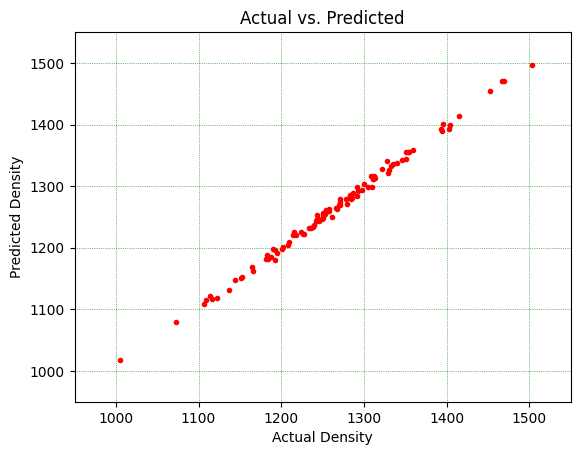

In [12]:
from chemml.visualization import scatter2D, SavePlot, decorator
import pandas as pd
%matplotlib inline
df_viz = pd.DataFrame()
df_viz["Actual"] = targets.reshape(-1,)
df_viz["Predicted"] = y_pred.reshape(-1,)
sc = scatter2D('r', marker='.')
fig = sc.plot(dfx=df_viz, dfy=df_viz, x="Actual", y="Predicted")

dec = decorator(title='Actual vs. Predicted',xlabel='Actual Density', ylabel='Predicted Density',
                xlim= (950,1550), ylim=(950,1550), grid=True, 
                grid_color='g', grid_linestyle=':', grid_linewidth=0.5)
fig = dec.fit(fig)
# print(type(fig))
sa=SavePlot(filename='Parity',output_directory='./automl_results/val/images',
            kwargs={'facecolor':'w','dpi':330,'pad_inches':0.1, 'bbox_inches':'tight'})
sa.save(obj=fig)
fig.show()